# Accuracy of SABR Density Approximations

We compare the risk-neutral PDF extracted via the **Breeden–Litzenberger formula**
$$p(K) = \frac{\partial^2 C}{\partial K^2}$$
from two analytic price representations against a Monte Carlo benchmark.

**Model — Normal SABR ($\beta = 0$):**
$$dF_t = \alpha_t\,dW_t, \quad d\alpha_t = \nu\,\alpha_t\,dB_t, \quad d\langle W,B\rangle_t = \rho\,dt$$

| Method | Reference |
|---|---|
| Hagan + BL | Hagan *et al.* (2002) perturbation IV → BS price → $\partial^2_K C$ |
| Korn–Tang + BL | Korn & Tang (2019) exact call price (hyperbolic geometry) → $\partial^2_K C$ |
| MC (KDE) | Euler–Maruyama with antithetic variates, Gaussian KDE |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm, gaussian_kde

from utils import implied_vol, bs_call_price

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
def simulate_normal_sabr(f0, alpha, rho, nu, T, steps=200, paths=200_000, seed=0):
    """Normal SABR (β=0) Euler–Maruyama with antithetic variates.
    Returns 2*paths terminal forward prices."""
    rng = np.random.default_rng(seed)
    dt = T / steps
    Z = rng.standard_normal((2, steps, paths))
    Z = np.concatenate([Z, -Z], axis=2)          # antithetic: doubles paths
    n = Z.shape[2]
    log_a = np.cumsum(nu * np.sqrt(dt) * Z[0] - 0.5 * nu**2 * dt, axis=0)
    A = alpha * np.exp(np.vstack([np.zeros(n), log_a]))   # shape (steps+1, n)
    dW = (rho * Z[0] + np.sqrt(1 - rho**2) * Z[1]) * np.sqrt(dt)
    return f0 + np.sum(A[:-1] * dW, axis=0)

In [3]:
def hagan_iv(f0, alpha, rho, nu, T, K):
    """Hagan et al. (2002) log-normal IV approximation for normal SABR (β=0), 4th-order."""
    K = np.asarray(K, dtype=float)
    atm = np.abs(f0 - K) < 1e-10
    z = np.where(atm, 0.0, nu / alpha * np.sqrt(f0 * K) * np.log(f0 / K))
    x = np.where(atm, 1.0, np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho)))
    zx = np.where(atm, 1.0,
         np.where(np.abs(x) > 1e-15,
                  np.log(f0 / K) * z / ((f0 - K) * x), 1.0))
    corr = 1 + T * (alpha**2 / (24 * f0 * K) + (2 - 3*rho**2) / 24 * nu**2)
    return alpha * zx * corr


def hagan_call(f0, alpha, rho, nu, T, K):
    """Call prices via Hagan IV plugged into Black–Scholes."""
    K = np.asarray(K, dtype=float)
    iv = hagan_iv(f0, alpha, rho, nu, T, K)
    return np.array([bs_call_price(f0, s, T, k) for s, k in zip(iv, K)])

In [4]:
def korn_call(f0, alpha, rho, nu, T, K):
    """Exact normal SABR (β=0) call price via Korn & Tang (2019).

    Represents the call as an integral over hyperbolic distance using the
    exact distribution of the hyperbolic Brownian motion joint with the
    stochastic volatility process.
    """
    t_p = nu**2 * T / 2
    m = f0 - K

    L = (-rho * ((K - f0) * nu + alpha * rho)
         + np.sqrt(alpha**2 + 2*alpha*nu*rho*(K - f0) + nu**2*(K - f0)**2))
    b_min = np.arccosh(L / (alpha * (1 - rho**2)))

    def integrand_outer(b):
        eb, cb = np.exp(b), np.cosh(b)
        G = -np.exp(-b / 2) * (
            -1 - eb
            + (2*norm.cdf((b - t_p) / np.sqrt(2*t_p)) - 1)
            + eb * (2*norm.cdf((b + t_p) / np.sqrt(2*t_p)) - 1)
        ) / (8 * np.pi)

        P = -2*m*nu*rho + 2*alpha*rho**2 + 2*alpha*cb*(1 - rho**2)
        Q = max(4*(-alpha**2 - m**2*nu**2 + 2*m*alpha*nu*rho) + P**2, 0.0)
        a_lo, a_hi = (P - np.sqrt(Q)) / 2, (P + np.sqrt(Q)) / 2

        def D(u):
            num = (-nu*m - rho*u + rho*alpha)**2 + (1 - rho**2)*(u - alpha)**2
            return np.arccosh(1 + num / (2*(1 - rho**2)*u*alpha))

        inner, _ = quad(
            lambda u: 1.0 / np.sqrt(max(cb - np.cosh(D(u)), 1e-30)),
            a_lo, a_hi, limit=100, epsabs=1e-8, epsrel=1e-8
        )
        return G * inner

    outer, _ = quad(integrand_outer, b_min, 30, limit=500, epsabs=1e-8, epsrel=1e-8)
    return max(f0 - K, 0.0) + np.sqrt(2) / (nu * np.sqrt(1 - rho**2)) * outer

In [5]:
def bl_pdf(call_fn, K_grid):
    """Breeden–Litzenberger: p(K) = d²C/dK² via numerical second derivative."""
    C = call_fn(K_grid)
    return np.maximum(np.gradient(np.gradient(C, K_grid), K_grid), 0.0)


def mc_pdf(samples, K_grid):
    """Gaussian KDE density from MC terminal samples, evaluated on K_grid."""
    return gaussian_kde(samples, bw_method='scott')(K_grid)


def mc_iv_smile(f0, T, K_arr, samples):
    """Log-normal IV smile from MC call prices (undiscounted)."""
    prices = np.mean(np.maximum(samples[:, None] - K_arr[None, :], 0), axis=0)
    return implied_vol(f0, T, K_arr, prices)

## Experiment

Fix $f_0 = 100$, $\alpha = 0.5$, $T = 1$; vary $(\rho, \nu)$ to cover three qualitatively different
regimes:

| Case | $\rho$ | $\nu$ | Characteristic |
|---|---|---|---|
| A | $-0.5$ | $0.4$ | Moderate skew, low vol-of-vol |
| B | $0.0$ | $0.6$ | Symmetric smile, medium vol-of-vol |
| C | $-0.7$ | $0.9$ | Strong skew + high vol-of-vol (stress test) |

**Left column:** Log-normal IV smile. **Right column:** Risk-neutral PDF.
Korn–Tang involves a double numerical integral per strike (slow; ~60 points computed).

/var/folders/yd/y8d3h3715d90250wmsk054j00000gn/T/ipykernel_58358/2400841423.py:31: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  inner, _ = quad(


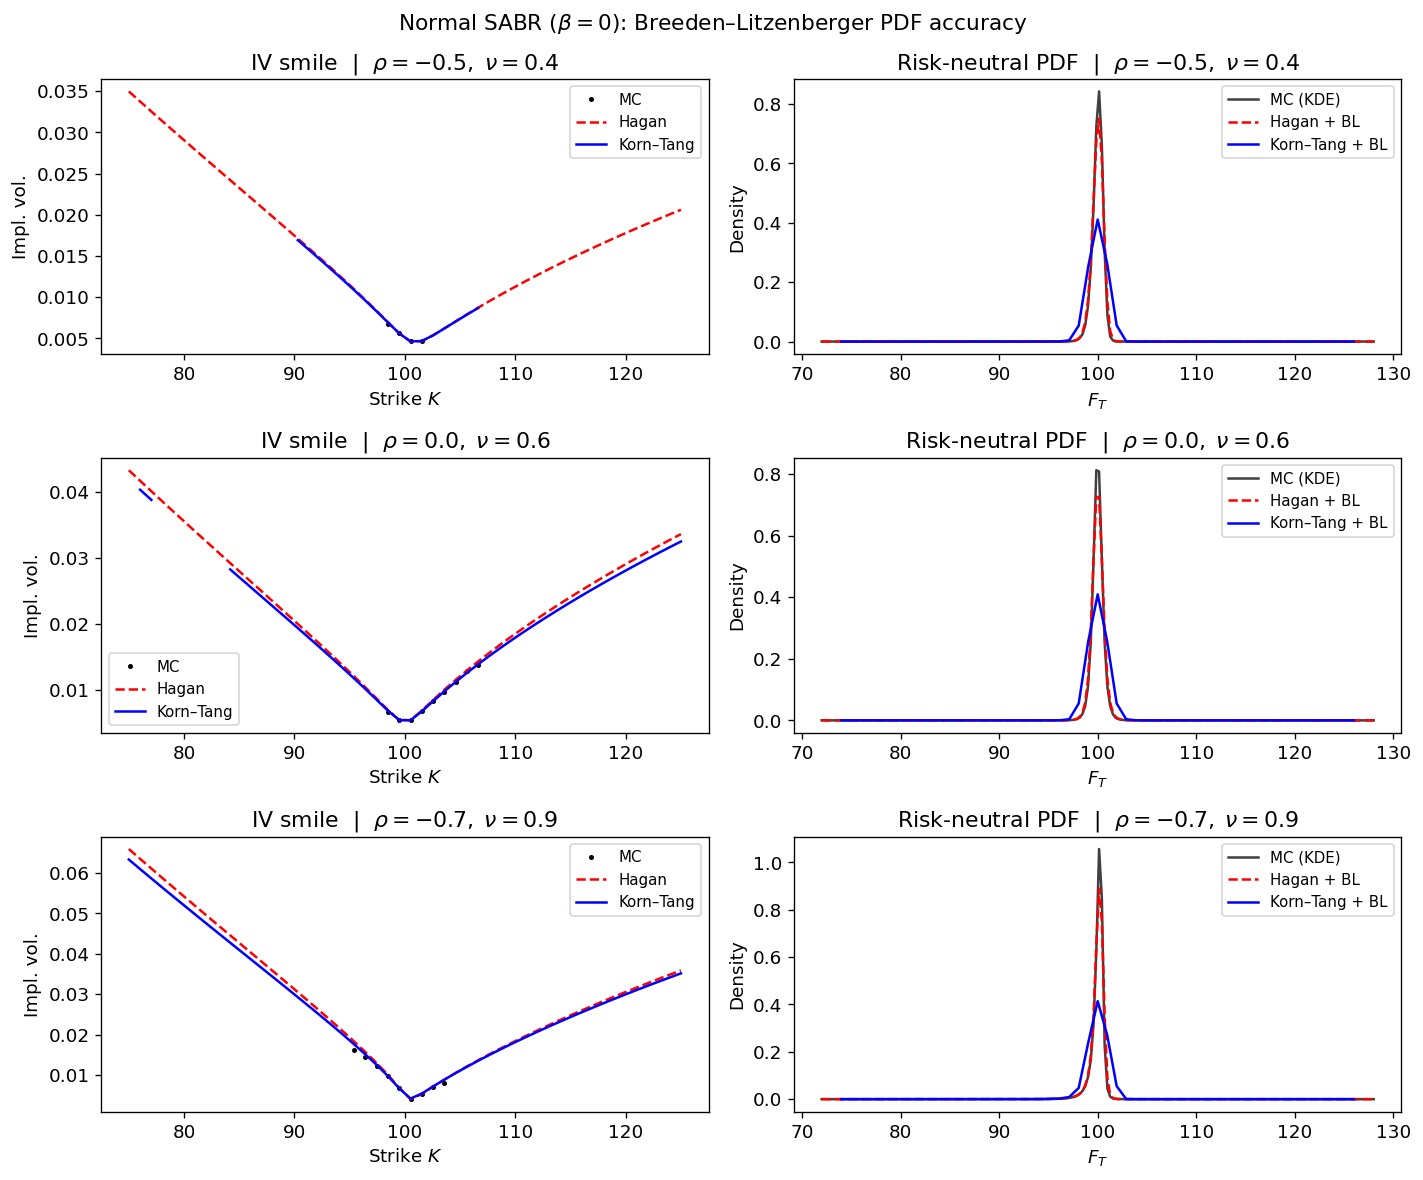

In [6]:
f0, T = 100.0, 1.0

PARAM_SETS = [
    dict(alpha=0.5, rho=-0.5, nu=0.4, label=r"$\rho{=}{-}0.5,\;\nu{=}0.4$"),
    dict(alpha=0.5, rho= 0.0, nu=0.6, label=r"$\rho{=}0.0,\;\nu{=}0.6$"),
    dict(alpha=0.5, rho=-0.7, nu=0.9, label=r"$\rho{=}{-}0.7,\;\nu{=}0.9$"),
]

K_pdf   = np.linspace(72, 128, 200)   # fine grid for BL second derivative
K_smile = np.linspace(75, 125, 50)    # coarser for IV display
K_korn  = np.linspace(74, 126, 55)    # Korn–Tang BL grid (double-integral per point)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle(r"Normal SABR ($\beta=0$): Breeden–Litzenberger PDF accuracy", fontsize=13)

for row, p in enumerate(PARAM_SETS):
    alpha, rho, nu = p['alpha'], p['rho'], p['nu']

    # ── MC benchmark ────────────────────────────────────────────────────────
    samples = simulate_normal_sabr(f0, alpha, rho, nu, T)

    # ── IV smiles ────────────────────────────────────────────────────────────
    iv_hagan = hagan_iv(f0, alpha, rho, nu, T, K_smile)
    iv_korn  = np.array([implied_vol(f0, T, k, korn_call(f0, alpha, rho, nu, T, k))
                         for k in K_smile])
    iv_mc    = mc_iv_smile(f0, T, K_smile, samples)

    ax = axes[row, 0]
    ax.plot(K_smile, iv_mc,    'k.',  ms=4,  label='MC')
    ax.plot(K_smile, iv_hagan, 'r--', lw=1.5, label='Hagan')
    ax.plot(K_smile, iv_korn,  'b-',  lw=1.5, label='Korn–Tang')
    ax.set(title=f'IV smile  |  {p["label"]}', xlabel='Strike $K$', ylabel='Impl. vol.')
    ax.legend(fontsize=9)

    # ── PDFs via Breeden–Litzenberger ────────────────────────────────────────
    C_korn   = np.array([korn_call(f0, alpha, rho, nu, T, k) for k in K_korn])
    pdf_korn = np.maximum(np.gradient(np.gradient(C_korn, K_korn), K_korn), 0.0)

    pdf_hagan = bl_pdf(
        lambda K, a=alpha, r=rho, v=nu: hagan_call(f0, a, r, v, T, K),
        K_pdf
    )
    pdf_mc = mc_pdf(samples, K_pdf)

    ax = axes[row, 1]
    ax.plot(K_pdf,  pdf_mc,    'k',   lw=1.5, alpha=0.75, label='MC (KDE)')
    ax.plot(K_pdf,  pdf_hagan, 'r--', lw=1.5, label='Hagan + BL')
    ax.plot(K_korn, pdf_korn,  'b-',  lw=1.5, label='Korn–Tang + BL')
    ax.set(title=f'Risk-neutral PDF  |  {p["label"]}', xlabel='$F_T$', ylabel='Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sabr_accuracy.pdf', bbox_inches='tight')
plt.show()